## Objective

The objective of this task is to analyze Zomato restaurant data to identify insights related to restaurant ratings, cuisines, location preferences, restaurant types, online ordering, table booking, and price patterns. The goal is to clean the dataset, perform exploratory data analysis, create meaningful visualizations, and provide practical recommendations for an Alfido Tech style food or restaurant platform.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/InternSpark Data Science Internship/Datasets/Zomato-Dataset/zomato.csv"

df = pd.read_csv(dataset_path)

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (56252, 13)

Columns:
['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']

Data Types:
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                          object
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
listed_in(type)                object
dtype: object

Missing Values:
address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                     

In [4]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())
df.head()

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for_two_people)', 'listed_in(type)']


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for_two_people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [5]:
df = df.rename(columns={
    "approx_cost(for_two_people)": "cost_for_two",
    "listed_in(type)": "listed_type"
})

print(df.columns.tolist())

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'listed_type']


In [6]:
# Check unique values in rate column
df["rate"].unique()[:20]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5',
       '\\nTop floor', '4.2/5', '3.9/5', '3.1/5', '3.0/5', '3.2/5',
       '3.3/5', '2.8/5', " ('Rated 1.0'", " ('Rated 5.0'", '4.4/5',
       ' always a good experience',
       ' a mocktail and did i just hear unlimited desserts?!\\nGoodbye midweek blues!!!?\\n\\nI would specially mention the staff here-Chaitanya',
       '4.3/5'], dtype=object)

In [7]:
# Clean rate column
df["rate"] = df["rate"].astype(str)

df["rate"] = df["rate"].replace({
    "NEW": np.nan,
    "-": np.nan,
    "nan": np.nan
})

df["rate"] = df["rate"].str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print(df["rate"].head())
print("Missing ratings:", df["rate"].isnull().sum())

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64
Missing ratings: 14587


In [8]:
# Clean cost_for_two column
df["cost_for_two"] = df["cost_for_two"].astype(str)
df["cost_for_two"] = df["cost_for_two"].str.replace(",", "", regex=False)
df["cost_for_two"] = pd.to_numeric(df["cost_for_two"], errors="coerce")

print(df["cost_for_two"].head())
print("Missing cost values:", df["cost_for_two"].isnull().sum())

0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
Name: cost_for_two, dtype: float64
Missing cost values: 4881


In [9]:
# Fill missing numerical values with median
df["rate"] = df["rate"].fillna(df["rate"].median())
df["cost_for_two"] = df["cost_for_two"].fillna(df["cost_for_two"].median())

# Fill missing categorical/text values
text_cols = ["location", "rest_type", "cuisines", "dish_liked", "listed_type", "online_order", "book_table"]

for col in text_cols:
    df[col] = df[col].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
address           17
name              16
online_order       0
book_table         0
rate               0
votes             78
phone           1296
location           0
rest_type          0
dish_liked         0
cuisines           0
cost_for_two       0
listed_type        0
dtype: int64


In [10]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Duplicate rows before: 17932
Duplicate rows after: 0
Final dataset shape: (38320, 13)


In [11]:
print("Average Rating:", round(df["rate"].mean(), 2))
print("Average Cost for Two:", round(df["cost_for_two"].mean(), 2))
print("Total Restaurants:", df["name"].nunique())
print("Total Locations:", df["location"].nunique())
print("Total Restaurant Types:", df["rest_type"].nunique())
print("Total Listed Types:", df["listed_type"].nunique())

Average Rating: 3.72
Average Cost for Two: 563.9
Total Restaurants: 11914
Total Locations: 2921
Total Restaurant Types: 2962
Total Listed Types: 2784


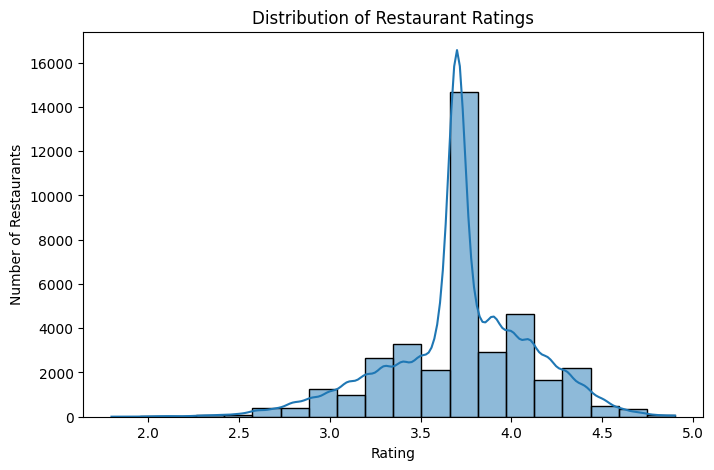

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["rate"], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

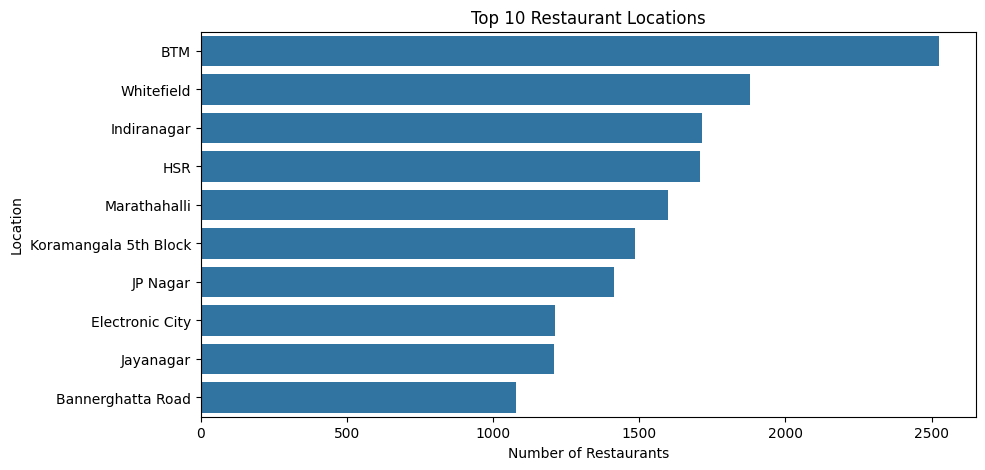

In [13]:
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()

In [20]:
# Keep only valid rows where online_order and book_table have proper Yes/No values
df["online_order"] = df["online_order"].astype(str).str.strip()
df["book_table"] = df["book_table"].astype(str).str.strip()

valid_rows = (
    df["online_order"].isin(["Yes", "No"]) &
    df["book_table"].isin(["Yes", "No"])
)

print("Rows before filtering:", df.shape[0])

df = df[valid_rows].copy()

print("Rows after filtering:", df.shape[0])

# Make sure rating is numeric and valid
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
df = df[(df["rate"] >= 0) & (df["rate"] <= 5)]

# Make sure cost and votes are numeric
df["cost_for_two"] = pd.to_numeric(df["cost_for_two"], errors="coerce")
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

df["cost_for_two"] = df["cost_for_two"].fillna(df["cost_for_two"].median())
df["votes"] = df["votes"].fillna(0)

print("Final cleaned shape:", df.shape)

print("\nOnline order values:")
print(df["online_order"].value_counts())

print("\nBook table values:")
print(df["book_table"].value_counts())

Rows before filtering: 38320
Rows after filtering: 34179
Final cleaned shape: (34179, 13)

Online order values:
online_order
Yes    20726
No     13453
Name: count, dtype: int64

Book table values:
book_table
No     29189
Yes     4990
Name: count, dtype: int64


In [21]:
df[["online_order", "book_table", "rate", "cost_for_two", "votes"]].head()

,online_order,book_table,rate,cost_for_two,votes
0,Yes,Yes,4.1,800.0,775
1,Yes,No,4.1,800.0,787
2,Yes,No,3.8,800.0,918
3,No,No,3.7,300.0,88
4,No,No,3.8,600.0,166


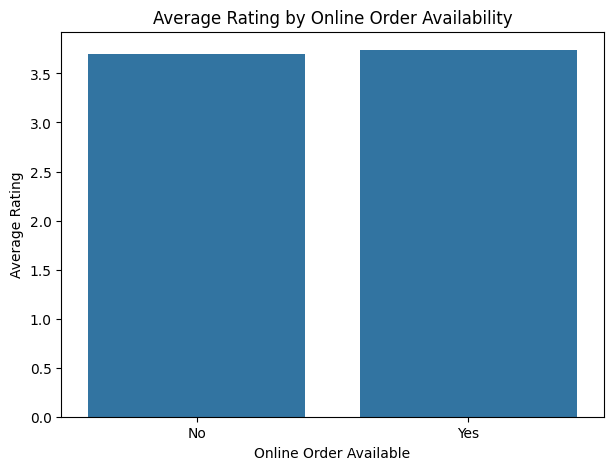

,online_order,rate
0,No,3.694812
1,Yes,3.738198


In [22]:
online_rating = df.groupby("online_order")["rate"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=online_rating, x="online_order", y="rate")
plt.title("Average Rating by Online Order Availability")
plt.xlabel("Online Order Available")
plt.ylabel("Average Rating")
plt.show()

online_rating

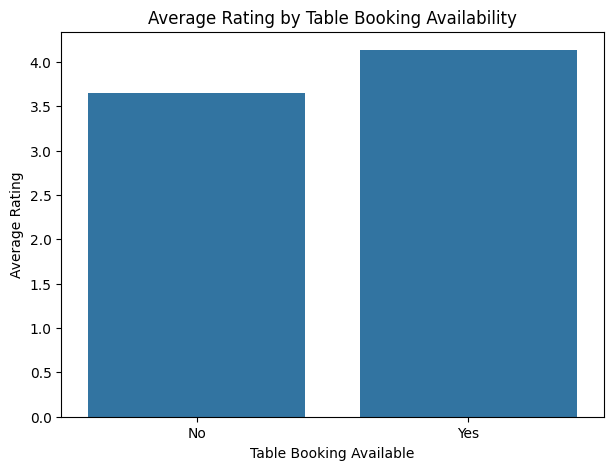

In [23]:
booking_rating = df.groupby("book_table")["rate"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=booking_rating, x="book_table", y="rate")
plt.title("Average Rating by Table Booking Availability")
plt.xlabel("Table Booking Available")
plt.ylabel("Average Rating")
plt.show()

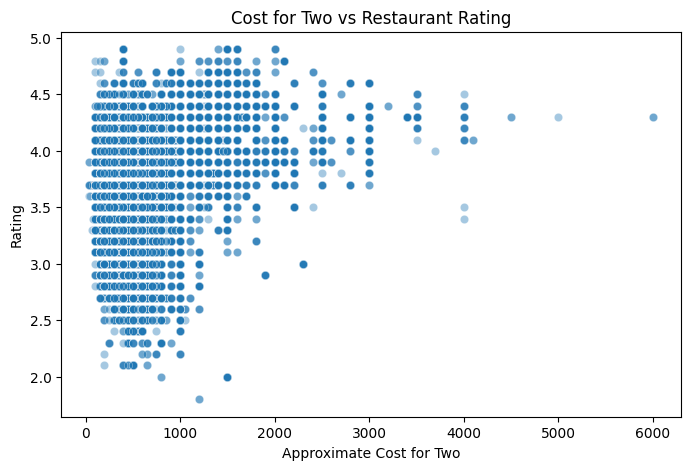

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="cost_for_two", y="rate", alpha=0.4)
plt.title("Cost for Two vs Restaurant Rating")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Rating")
plt.show()

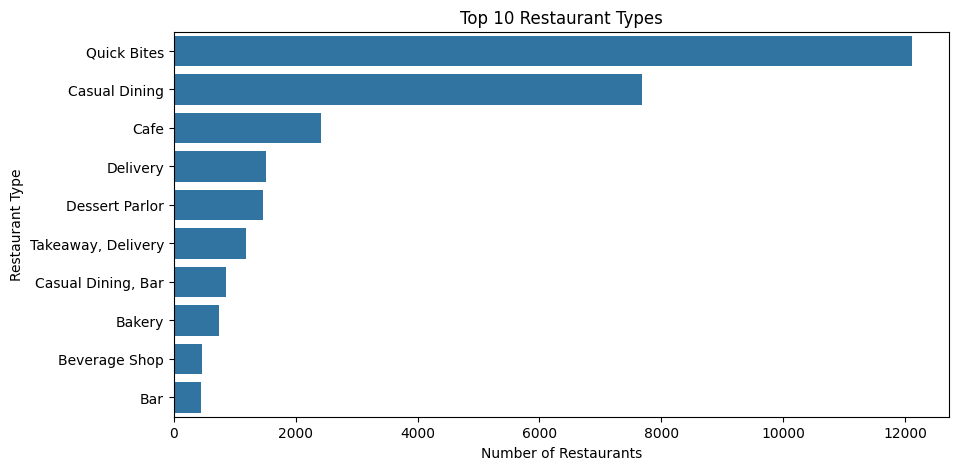

In [25]:
top_rest_types = df["rest_type"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_rest_types.values, y=top_rest_types.index)
plt.title("Top 10 Restaurant Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Type")
plt.show()

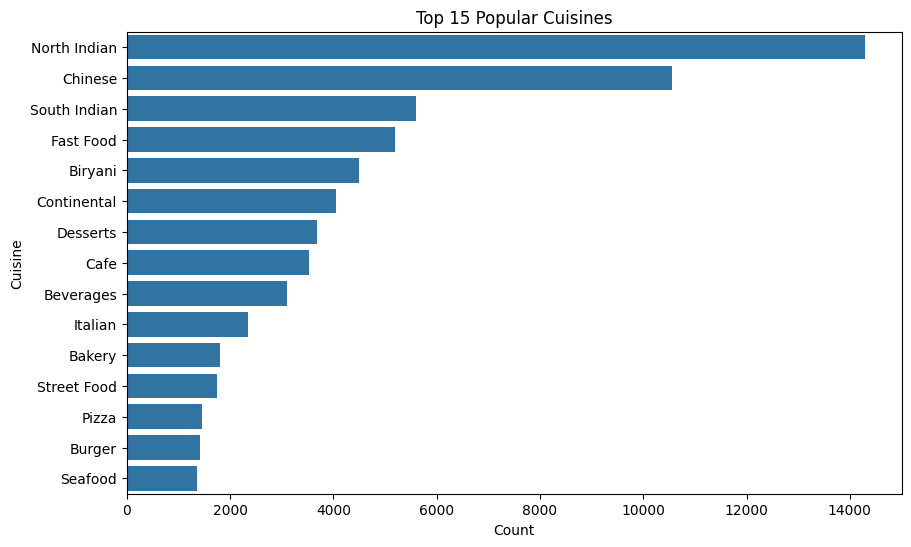

In [26]:
from collections import Counter

cuisine_list = []

for cuisines in df["cuisines"]:
    for cuisine in str(cuisines).split(","):
        cuisine_list.append(cuisine.strip())

top_cuisines = pd.DataFrame(
    Counter(cuisine_list).most_common(15),
    columns=["Cuisine", "Count"]
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_cuisines, x="Count", y="Cuisine")
plt.title("Top 15 Popular Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

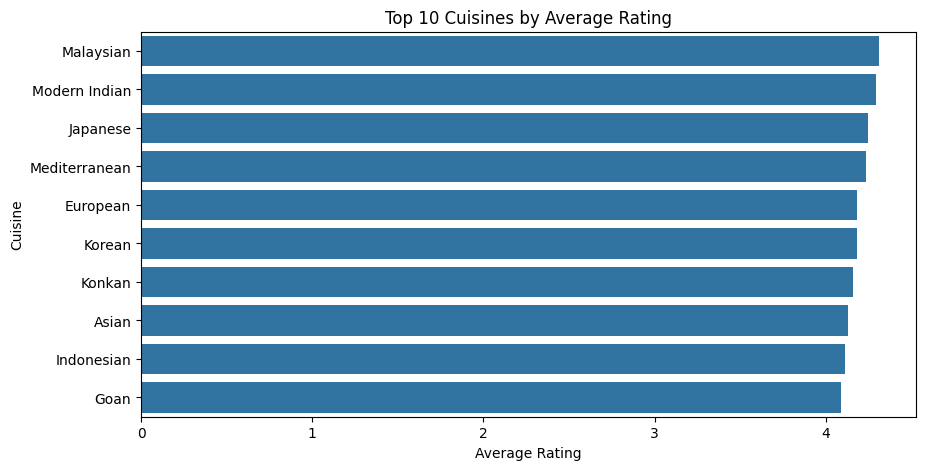

In [27]:
# Explode cuisines for cuisine-level rating analysis
cuisine_rating_data = df[["cuisines", "rate"]].copy()
cuisine_rating_data["cuisines"] = cuisine_rating_data["cuisines"].astype(str).str.split(",")

cuisine_rating_data = cuisine_rating_data.explode("cuisines")
cuisine_rating_data["cuisines"] = cuisine_rating_data["cuisines"].str.strip()

# Keep cuisines with enough restaurants for fair comparison
cuisine_counts = cuisine_rating_data["cuisines"].value_counts()
valid_cuisines = cuisine_counts[cuisine_counts >= 50].index

top_cuisine_ratings = (
    cuisine_rating_data[cuisine_rating_data["cuisines"].isin(valid_cuisines)]
    .groupby("cuisines")["rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cuisine_ratings, x="rate", y="cuisines")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()

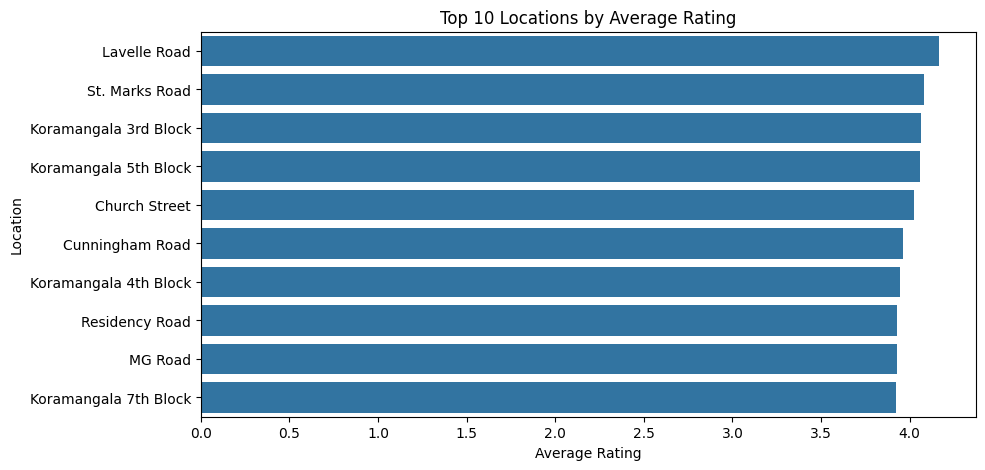

In [28]:
location_rating = (
    df.groupby("location")
    .agg(avg_rating=("rate", "mean"), restaurant_count=("name", "count"))
    .reset_index()
)

# Keep locations with at least 100 restaurants for reliable comparison
location_rating_filtered = location_rating[location_rating["restaurant_count"] >= 100]

top_location_ratings = location_rating_filtered.sort_values(by="avg_rating", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_location_ratings, x="avg_rating", y="location")
plt.title("Top 10 Locations by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Location")
plt.show()

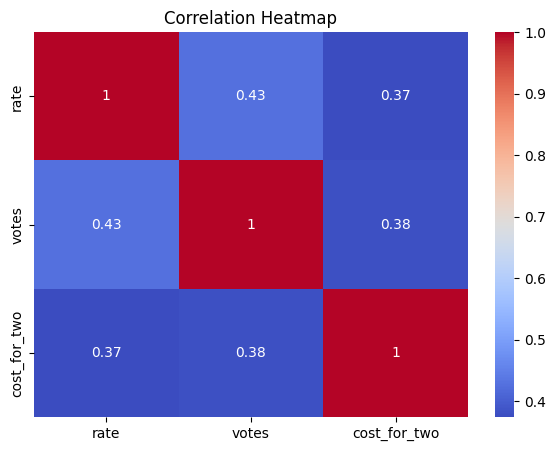

In [29]:
numeric_cols = ["rate", "votes", "cost_for_two"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [30]:
from wordcloud import WordCloud

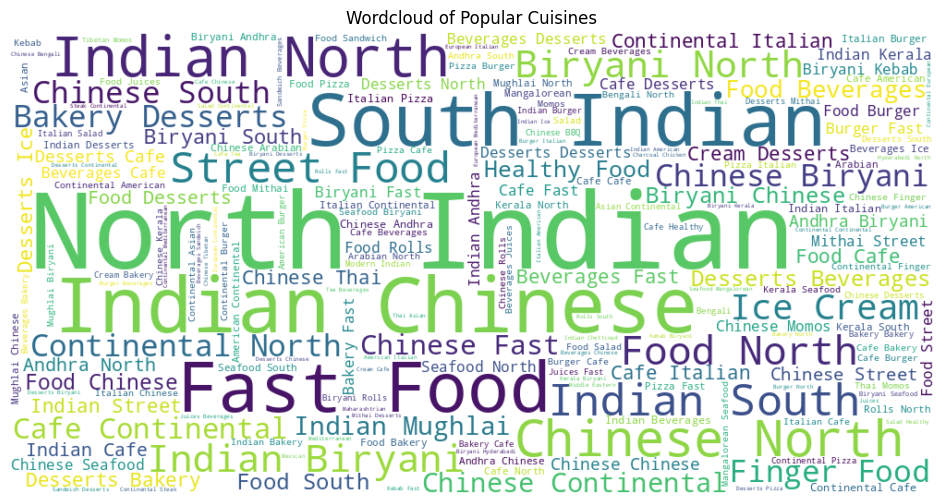

In [31]:
cuisine_text = " ".join(cuisine_list)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(cuisine_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Popular Cuisines")
plt.show()

In [32]:
best_online = online_rating.sort_values(by="rate", ascending=False).iloc[0]
best_booking = booking_rating.sort_values(by="rate", ascending=False).iloc[0]
most_common_location = df["location"].value_counts().idxmax()
most_common_cuisine = top_cuisines.iloc[0]["Cuisine"]
best_cuisine = top_cuisine_ratings.iloc[0]["cuisines"]
best_location = top_location_ratings.iloc[0]["location"]

print("KEY INSIGHTS")
print("-" * 60)
print(f"Average restaurant rating: {round(df['rate'].mean(), 2)}")
print(f"Most common restaurant location: {most_common_location}")
print(f"Most popular cuisine: {most_common_cuisine}")
print(f"Highest-rated cuisine among common cuisines: {best_cuisine}")
print(f"Highest-rated location among active locations: {best_location}")
print(f"Online order category with higher average rating: {best_online['online_order']}")
print(f"Table booking category with higher average rating: {best_booking['book_table']}")

KEY INSIGHTS
------------------------------------------------------------
Average restaurant rating: 3.72
Most common restaurant location: BTM
Most popular cuisine: North Indian
Highest-rated cuisine among common cuisines: Malaysian
Highest-rated location among active locations: Lavelle Road
Online order category with higher average rating: Yes
Table booking category with higher average rating: Yes


In [33]:
print("RECOMMENDATIONS FOR ALFIDO TECH STYLE PLATFORM")
print("-" * 70)

print("1. Focus partnerships in high-density restaurant locations.")
print("   Locations with many restaurants can provide better business opportunities and more user choice.")

print("\n2. Promote popular cuisines through curated content.")
print("   Cuisine popularity can be used to create food guides, recommendation lists, and targeted campaigns.")

print("\n3. Highlight high-rated restaurants with strong customer trust.")
print("   Restaurants with better ratings and votes can be promoted as trusted choices.")

print("\n4. Use price and rating insights for budget-friendly recommendations.")
print("   Grouping restaurants by price range can help users find suitable options based on affordability.")

print("\n5. Encourage restaurants to support online ordering and table booking.")
print("   These features improve user convenience and can be used as filters in a restaurant discovery platform.")

RECOMMENDATIONS FOR ALFIDO TECH STYLE PLATFORM
----------------------------------------------------------------------
1. Focus partnerships in high-density restaurant locations.
   Locations with many restaurants can provide better business opportunities and more user choice.

2. Promote popular cuisines through curated content.
   Cuisine popularity can be used to create food guides, recommendation lists, and targeted campaigns.

3. Highlight high-rated restaurants with strong customer trust.
   Restaurants with better ratings and votes can be promoted as trusted choices.

4. Use price and rating insights for budget-friendly recommendations.
   Grouping restaurants by price range can help users find suitable options based on affordability.

5. Encourage restaurants to support online ordering and table booking.
   These features improve user convenience and can be used as filters in a restaurant discovery platform.
